# Vibe Matcher - AI Fashion Recommendation System

## Introduction
I’m excited about AI at Nexora because your focus on building real, user-centric personalization systems aligns directly with the kind of work I enjoy. My recent projects using vector search, embeddings and scalable full-stack architectures have shown me how meaningful it is when technology can actually understand user intent, not just respond to it. Nexora feels like a place where I can apply that experience in a practical, product-focused environment while continuing to grow in recommendation systems and applied machine learning. I’m particularly drawn to Nexora’s balance of creative experimentation and engineering rigor, and I’d like to contribute to building systems that make discovery, taste and experience feel personal and intuitive at scale




## 1. Import Required Libraries

In [12]:
# Import necessary libraries for the Vibe Matcher system
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import timeit
import warnings
from typing import List, Dict, Tuple
import json
from datetime import datetime

# Machine Learning & NLP
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

# Sentence Transformers for FREE embeddings
try:
    from sentence_transformers import SentenceTransformer
    SENTENCE_TRANSFORMERS_AVAILABLE = True
    print(" Sentence Transformers imported successfully")
except ImportError:
    print(" Sentence Transformers not found. Install with: pip install sentence-transformers")
    SENTENCE_TRANSFORMERS_AVAILABLE = False

# Set up plotting style
plt.style.use('seaborn-v0_8')
warnings.filterwarnings('ignore')

print(" All libraries imported successfully!")
print(f" Notebook initialized at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(" Using FREE Sentence Transformers for embeddings")

 Sentence Transformers imported successfully
 All libraries imported successfully!
 Notebook initialized at: 2025-11-11 14:01:43
 Using FREE Sentence Transformers for embeddings


## 2. Create Mock Fashion Dataset

In [13]:
# Create comprehensive mock fashion dataset
fashion_products = [
    {
        "id": 1,
        "name": "Boho Maxi Dress",
        "description": "Flowy, earthy tones maxi dress perfect for festival vibes with intricate embroidered details and bell sleeves",
        "price": 89.99,
        "category": "Dresses",
        "vibe_tags": ["boho", "festival", "free-spirited", "earthy", "flowing"]
    },
    {
        "id": 2,
        "name": "Urban Street Bomber",
        "description": "Edgy black bomber jacket with neon accents, perfect for energetic urban street style and night adventures",
        "price": 129.99,
        "category": "Jackets",
        "vibe_tags": ["urban", "edgy", "street", "energetic", "modern"]
    },
    {
        "id": 3,
        "name": "Cozy Oversized Sweater",
        "description": "Ultra-soft cashmere blend oversized sweater in warm cream, ideal for cozy weekend moments and comfort",
        "price": 159.99,
        "category": "Knitwear",
        "vibe_tags": ["cozy", "comfort", "weekend", "soft", "relaxed"]
    },
    {
        "id": 4,
        "name": "Minimalist Silk Blouse",
        "description": "Clean lines elegant silk blouse in ivory white, sophisticated simplicity for professional elegance",
        "price": 119.99,
        "category": "Tops",
        "vibe_tags": ["minimalist", "elegant", "professional", "clean", "sophisticated"]
    },
    {
        "id": 5,
        "name": "Vintage Denim Jacket",
        "description": "Classic distressed denim jacket with retro patches, bringing nostalgic vintage charm to any outfit",
        "price": 79.99,
        "category": "Jackets",
        "vibe_tags": ["vintage", "retro", "classic", "nostalgic", "casual"]
    },
    {
        "id": 6,
        "name": "Athletic Yoga Set",
        "description": "High-performance moisture-wicking yoga set in sage green, designed for active wellness and mindful movement",
        "price": 89.99,
        "category": "Activewear",
        "vibe_tags": ["athletic", "wellness", "active", "mindful", "performance"]
    },
    {
        "id": 7,
        "name": "Romantic Lace Top",
        "description": "Delicate floral lace top in blush pink, feminine and romantic with intricate details for special occasions",
        "price": 69.99,
        "category": "Tops",
        "vibe_tags": ["romantic", "feminine", "delicate", "special", "lace"]
    },
    {
        "id": 8,
        "name": "Grunge Plaid Shirt",
        "description": "Oversized flannel shirt in dark plaid pattern, capturing authentic grunge aesthetic with rebellious edge",
        "price": 59.99,
        "category": "Tops",
        "vibe_tags": ["grunge", "rebellious", "alternative", "flannel", "oversized"]
    },
    {
        "id": 9,
        "name": "Luxury Cashmere Coat",
        "description": "Premium cashmere long coat in charcoal grey, timeless luxury and sophistication for formal occasions",
        "price": 449.99,
        "category": "Outerwear",
        "vibe_tags": ["luxury", "sophisticated", "timeless", "formal", "premium"]
    },
    {
        "id": 10,
        "name": "Bohemian Kimono Cardigan",
        "description": "Flowing kimono-style cardigan with paisley print, perfect for bohemian layering and artistic expression",
        "price": 94.99,
        "category": "Cardigans",
        "vibe_tags": ["bohemian", "artistic", "flowing", "layering", "paisley"]
    }
]

# Create DataFrame
df = pd.DataFrame(fashion_products)

# Display dataset overview
print(" Fashion Product Dataset Overview")
print(f" Total products: {len(df)}")
print(f" Categories: {df['category'].unique()}")
print(f" Price range: ${df['price'].min():.2f} - ${df['price'].max():.2f}")

# Display sample products
print("\n Sample Products:")
display(df[['name', 'description', 'price', 'vibe_tags']].head())

 Fashion Product Dataset Overview
 Total products: 10
 Categories: ['Dresses' 'Jackets' 'Knitwear' 'Tops' 'Activewear' 'Outerwear'
 'Cardigans']
 Price range: $59.99 - $449.99

 Sample Products:


,name,description,price,vibe_tags
0,Boho Maxi Dress,"Flowy, earthy tones maxi dress perfect for fes...",89.99,"[boho, festival, free-spirited, earthy, flowing]"
1,Urban Street Bomber,"Edgy black bomber jacket with neon accents, pe...",129.99,"[urban, edgy, street, energetic, modern]"
2,Cozy Oversized Sweater,Ultra-soft cashmere blend oversized sweater in...,159.99,"[cozy, comfort, weekend, soft, relaxed]"
3,Minimalist Silk Blouse,Clean lines elegant silk blouse in ivory white...,119.99,"[minimalist, elegant, professional, clean, sop..."
4,Vintage Denim Jacket,Classic distressed denim jacket with retro pat...,79.99,"[vintage, retro, classic, nostalgic, casual]"


In [15]:
# Setup Sentence Transformers for FREE high-quality embeddings

if SENTENCE_TRANSFORMERS_AVAILABLE:
    try:
        # Load the model (downloads automatically on first use)
        print(" Loading Sentence Transformer model...")
        model = SentenceTransformer('all-MiniLM-L6-v2')
        
        # Model info
        print(" Model loaded successfully!")
        print(" Model: all-MiniLM-L6-v2")
        print(" Embedding dimensions: 384")
        
        
        
        def get_embedding(text: str) -> List[float]:
            """
            Generate embedding using Sentence Transformers
            
            Args:
                text (str): Text to embed
                
            Returns:
                List[float]: 384-dimensional embedding vector
            """
            try:
                # Clean text
                text = text.replace("\n", " ").strip()
                
                # Generate embedding
                embedding = model.encode(text)
                
                return embedding.tolist()
                
            except Exception as e:
                print(f"❌ Error generating embedding: {e}")
                # Fallback to random embedding
                return np.random.normal(size=384).tolist()
        
        EMBEDDING_DIM = 384
        EMBEDDING_SOURCE = "sentence-transformers"
        
    except Exception as e:
        print(f" Error loading Sentence Transformers: {e}")
        raise e
        
else:
    print(" Sentence Transformers not available")
    print(" Please install: pip install sentence-transformers")
    
    # Fallback function
    def get_embedding(text: str) -> List[float]:
        """Fallback random embeddings"""
        return np.random.normal(size=384).tolist()
    
    EMBEDDING_DIM = 384
    EMBEDDING_SOURCE = "fallback"

# Test the embedding system
sample_text = "Elegant minimalist style with clean lines"
sample_embedding = get_embedding(sample_text)

print(f"\n EMBEDDING TEST:")
print(f" Sample text: '{sample_text}'")
print(f" Source: {EMBEDDING_SOURCE}")
print(f" Dimensions: {len(sample_embedding)}")
print(f" Sample values: [{sample_embedding[0]:.4f}, {sample_embedding[1]:.4f}, ...]")
print(f" Embedding system ready!")

 Loading Sentence Transformer model...
 Model loaded successfully!
 Model: all-MiniLM-L6-v2
 Embedding dimensions: 384

 EMBEDDING TEST:
 Sample text: 'Elegant minimalist style with clean lines'
 Source: sentence-transformers
 Dimensions: 384
 Sample values: [-0.0634, 0.0851, ...]
 Embedding system ready!


## 4. Generate Product Embeddings

In [17]:
# Generate embeddings for all product descriptions using Sentence Transformers
print(" Generating product embeddings with Sentence Transformers...")
start_time = timeit.default_timer()

# Create combined text for embedding (description + vibe tags)
df['combined_text'] = df['description'] + " " + df['vibe_tags'].apply(lambda x: " ".join(x))

# Generate embeddings for each product
embeddings = []
for idx, row in df.iterrows():
    print(f"Processing product {idx + 1}/{len(df)}: {row['name']}")
    embedding = get_embedding(row['combined_text'])
    embeddings.append(embedding)

# Add embeddings to dataframe
df['embedding'] = embeddings

# Convert embeddings to numpy array for efficient computation
embedding_matrix = np.array(df['embedding'].tolist())

# Normalize embeddings for cosine similarity
normalized_embeddings = normalize(embedding_matrix, norm='l2')
df['normalized_embedding'] = list(normalized_embeddings)

generation_time = timeit.default_timer() - start_time

print(f" Successfully generated embeddings for {len(df)} products")
print(f" Generation time: {generation_time:.2f} seconds")
print(f" Embedding dimensions: {len(df['embedding'].iloc[0])}")
print(f" Embedding matrix shape: {embedding_matrix.shape}")


# Display embedding statistics
embedding_stats = {
    'mean': np.mean(embedding_matrix, axis=0).mean(),
    'std': np.std(embedding_matrix, axis=0).mean(),
    'min': np.min(embedding_matrix),
    'max': np.max(embedding_matrix)
}

print(f"\n Embedding Statistics:")
for stat, value in embedding_stats.items():
    print(f"   {stat.capitalize()}: {value:.4f}")

print(f"\n Ready for similarity matching!")

 Generating product embeddings with Sentence Transformers...
Processing product 1/10: Boho Maxi Dress
Processing product 2/10: Urban Street Bomber
Processing product 3/10: Cozy Oversized Sweater
Processing product 4/10: Minimalist Silk Blouse
Processing product 5/10: Vintage Denim Jacket
Processing product 6/10: Athletic Yoga Set
Processing product 7/10: Romantic Lace Top
Processing product 8/10: Grunge Plaid Shirt
Processing product 9/10: Luxury Cashmere Coat
Processing product 10/10: Bohemian Kimono Cardigan
 Successfully generated embeddings for 10 products
 Generation time: 1.42 seconds
 Embedding dimensions: 384
 Embedding matrix shape: (10, 384)

 Embedding Statistics:
   Mean: -0.0002
   Std: 0.0371
   Min: -0.1922
   Max: 0.1911

 Ready for similarity matching!


## 5. Implement Cosine Similarity Search

In [18]:
# Implement efficient cosine similarity search functions

def compute_similarity_scores(query_embedding: np.ndarray, product_embeddings: np.ndarray) -> np.ndarray:
    """
    Compute cosine similarity between query and all product embeddings
    
    Args:
        query_embedding: Query embedding vector
        product_embeddings: Matrix of product embeddings
        
    Returns:
        Array of similarity scores
    """
    # Ensure query embedding is 2D for sklearn
    if len(query_embedding.shape) == 1:
        query_embedding = query_embedding.reshape(1, -1)
    
    # Compute cosine similarity
    similarities = cosine_similarity(query_embedding, product_embeddings)[0]
    
    return similarities

def find_top_matches(similarities: np.ndarray, df: pd.DataFrame, top_k: int = 3) -> pd.DataFrame:
    """
    Find top K products with highest similarity scores
    
    Args:
        similarities: Array of similarity scores
        df: Product dataframe
        top_k: Number of top matches to return
        
    Returns:
        DataFrame with top matches and scores
    """
    # Get indices of top K similarities
    top_indices = np.argsort(similarities)[::-1][:top_k]
    
    # Create results dataframe
    results = df.iloc[top_indices].copy()
    results['similarity_score'] = similarities[top_indices]
    results['rank'] = range(1, len(results) + 1)
    
    return results[['rank', 'name', 'description', 'price', 'vibe_tags', 'similarity_score']]

# Test similarity computation
print(" Testing similarity computation...")

# Create a test query embedding
test_query = "elegant minimalist professional style"
test_embedding = get_embedding(test_query)
test_embedding_normalized = normalize([test_embedding], norm='l2')[0]

# Compute similarities with all products
test_similarities = compute_similarity_scores(test_embedding_normalized, normalized_embeddings)

print(f" Similarity computation successful!")
print(f" Similarity scores range: {test_similarities.min():.4f} to {test_similarities.max():.4f}")
print(f" Mean similarity: {test_similarities.mean():.4f}")

# Show top matches for test query
test_results = find_top_matches(test_similarities, df, top_k=3)
print(f"\n Top matches for '{test_query}':")
display(test_results)

 Testing similarity computation...
 Similarity computation successful!
 Similarity scores range: 0.1244 to 0.5657
 Mean similarity: 0.3255

 Top matches for 'elegant minimalist professional style':


,rank,name,description,price,vibe_tags,similarity_score
3,1,Minimalist Silk Blouse,Clean lines elegant silk blouse in ivory white...,119.99,"[minimalist, elegant, professional, clean, sop...",0.565676
0,2,Boho Maxi Dress,"Flowy, earthy tones maxi dress perfect for fes...",89.99,"[boho, festival, free-spirited, earthy, flowing]",0.364220
8,3,Luxury Cashmere Coat,"Premium cashmere long coat in charcoal grey, t...",449.99,"[luxury, sophisticated, timeless, formal, prem...",0.354744


## 6. Build Vibe Matcher Function

In [19]:
# Main Vibe Matcher recommendation function

class VibeMatcher:
    """
    Advanced fashion recommendation system using semantic embeddings
    """
    
    def __init__(self, products_df: pd.DataFrame, min_similarity_threshold: float = 0.3):
        self.products_df = products_df
        self.min_threshold = min_similarity_threshold
        self.normalized_embeddings = np.array(products_df['normalized_embedding'].tolist())
        
    def match_vibe(self, vibe_query: str, top_k: int = 3, return_scores: bool = True) -> Dict:
        """
        Find products that match the given vibe query
        
        Args:
            vibe_query (str): Natural language description of desired vibe
            top_k (int): Number of top recommendations to return
            return_scores (bool): Whether to include similarity scores
            
        Returns:
            Dict: Recommendation results with metadata
        """
        start_time = timeit.default_timer()
        
        try:
            # Generate query embedding
            query_embedding = get_embedding(vibe_query)
            query_embedding_normalized = normalize([query_embedding], norm='l2')[0]
            
            # Compute similarities
            similarities = compute_similarity_scores(query_embedding_normalized, self.normalized_embeddings)
            
            # Find top matches
            top_matches = find_top_matches(similarities, self.products_df, top_k)
            
            # Check if matches meet minimum threshold
            good_matches = top_matches[top_matches['similarity_score'] >= self.min_threshold]
            
            # Calculate metrics
            query_time = timeit.default_timer() - start_time
            avg_score = top_matches['similarity_score'].mean()
            
            # Prepare results
            results = {
                'query': vibe_query,
                'matches': top_matches,
                'good_matches_count': len(good_matches),
                'total_matches': len(top_matches),
                'average_score': avg_score,
                'max_score': top_matches['similarity_score'].max(),
                'query_time_ms': query_time * 1000,
                'success': len(good_matches) > 0
            }
            
            # Add fallback recommendation if no good matches
            if not results['success']:
                results['fallback_message'] = (f"No strong matches found for '{vibe_query}'. "
                                             f"Consider refining your query or exploring these related items:")
            
            return results
            
        except Exception as e:
            return {
                'query': vibe_query,
                'error': str(e),
                'success': False,
                'query_time_ms': (timeit.default_timer() - start_time) * 1000
            }

# Initialize Vibe Matcher
vibe_matcher = VibeMatcher(df, min_similarity_threshold=0.4)

print(" Vibe Matcher initialized successfully!")
print(f" Products indexed: {len(df)}")
print(f" Minimum similarity threshold: {vibe_matcher.min_threshold}")

# Test the vibe matcher
test_query = "energetic urban chic"
test_result = vibe_matcher.match_vibe(test_query)

print(f"\n Test Query: '{test_query}'")
print(f" Success: {test_result['success']}")
print(f" Query time: {test_result['query_time_ms']:.2f}ms")
print(f" Average similarity: {test_result['average_score']:.4f}")
print(f" Good matches: {test_result['good_matches_count']}/{test_result['total_matches']}")

if test_result['success']:
    print("\n Top Recommendations:")
    display(test_result['matches'])

 Vibe Matcher initialized successfully!
 Products indexed: 10
 Minimum similarity threshold: 0.4

 Test Query: 'energetic urban chic'
 Success: True
 Query time: 56.56ms
 Average similarity: 0.3518
 Good matches: 1/3

 Top Recommendations:


,rank,name,description,price,vibe_tags,similarity_score
1,1,Urban Street Bomber,"Edgy black bomber jacket with neon accents, pe...",129.99,"[urban, edgy, street, energetic, modern]",0.502389
0,2,Boho Maxi Dress,"Flowy, earthy tones maxi dress perfect for fes...",89.99,"[boho, festival, free-spirited, earthy, flowing]",0.311522
8,3,Luxury Cashmere Coat,"Premium cashmere long coat in charcoal grey, t...",449.99,"[luxury, sophisticated, timeless, formal, prem...",0.241417


## 7. Test with Sample Queries

In [20]:
# Comprehensive testing with diverse vibe queries

test_queries = [
    "energetic urban chic street style",
    "cozy weekend comfortable relaxation vibes",
    "elegant minimalist professional sophisticated",
    "bohemian free-spirited festival artistic",
    "vintage retro classic nostalgic charm"
]

# Store results for analysis
test_results = []

print(" Running comprehensive vibe matching tests...\n")

for i, query in enumerate(test_queries, 1):
    print(f"{'='*60}")
    print(f" Test {i}: '{query}'")
    print(f"{'='*60}")
    
    # Get recommendations
    result = vibe_matcher.match_vibe(query, top_k=3)
    test_results.append(result)
    
    # Display results
    if result['success']:
        print(f" Status: SUCCESS")
        print(f"  Query Time: {result['query_time_ms']:.2f}ms")
        print(f" Avg Similarity: {result['average_score']:.4f}")
        print(f" Good Matches: {result['good_matches_count']}/{result['total_matches']}")
        print(f" Best Match Score: {result['max_score']:.4f}")
        
        print("\n Top Recommendations:")
        for idx, row in result['matches'].iterrows():
            print(f"   {row['rank']}. {row['name']} (Score: {row['similarity_score']:.4f})")
            print(f"       ${row['price']} |  {', '.join(row['vibe_tags'][:3])}")
            
    else:
        print(f" Status: FAILED")
        print(f" Error: {result.get('error', 'Unknown error')}")
        if 'fallback_message' in result:
            print(f" {result['fallback_message']}")
    
    print("\n")

# Summary statistics
print(f"{'='*60}")
print(" TEST SUMMARY")
print(f"{'='*60}")

successful_tests = [r for r in test_results if r['success']]
total_tests = len(test_results)
success_rate = len(successful_tests) / total_tests * 100

print(f" Success Rate: {len(successful_tests)}/{total_tests} ({success_rate:.1f}%)")

if successful_tests:
    avg_query_time = np.mean([r['query_time_ms'] for r in successful_tests])
    avg_similarity = np.mean([r['average_score'] for r in successful_tests])
    total_good_matches = sum([r['good_matches_count'] for r in successful_tests])
    
    print(f" Avg Query Time: {avg_query_time:.2f}ms")
    print(f" Avg Similarity: {avg_similarity:.4f}")
    print(f" Total Good Matches: {total_good_matches}")
    print(f" Avg Good Matches per Query: {total_good_matches/len(successful_tests):.1f}")

 Running comprehensive vibe matching tests...

 Test 1: 'energetic urban chic street style'
 Status: SUCCESS
  Query Time: 82.84ms
 Avg Similarity: 0.4624
 Good Matches: 2/3
 Best Match Score: 0.6017

 Top Recommendations:
   1. Urban Street Bomber (Score: 0.6017)
       $129.99 |  urban, edgy, street
   2. Boho Maxi Dress (Score: 0.4003)
       $89.99 |  boho, festival, free-spirited
   3. Luxury Cashmere Coat (Score: 0.3851)
       $449.99 |  luxury, sophisticated, timeless


 Test 2: 'cozy weekend comfortable relaxation vibes'
 Status: SUCCESS
  Query Time: 76.04ms
 Avg Similarity: 0.3692
 Good Matches: 1/3
 Best Match Score: 0.4271

 Top Recommendations:
   1. Cozy Oversized Sweater (Score: 0.4271)
       $159.99 |  cozy, comfort, weekend
   2. Luxury Cashmere Coat (Score: 0.3409)
       $449.99 |  luxury, sophisticated, timeless
   3. Romantic Lace Top (Score: 0.3396)
       $69.99 |  romantic, feminine, delicate


 Test 3: 'elegant minimalist professional sophisticated'
 Status: 

## 8. Evaluate Performance Metrics

In [21]:
# Comprehensive performance evaluation and metrics analysis

def evaluate_system_performance(test_results: List[Dict]) -> Dict:
    """
    Evaluate the overall performance of the Vibe Matcher system
    """
    successful_results = [r for r in test_results if r['success']]
    
    if not successful_results:
        return {"error": "No successful tests to evaluate"}
    
    # Calculate comprehensive metrics
    metrics = {
        'system_metrics': {
            'total_queries': len(test_results),
            'successful_queries': len(successful_results),
            'success_rate': len(successful_results) / len(test_results) * 100,
            'failure_rate': (len(test_results) - len(successful_results)) / len(test_results) * 100
        },
        
        'similarity_metrics': {
            'avg_similarity_score': np.mean([r['average_score'] for r in successful_results]),
            'max_similarity_score': max([r['max_score'] for r in successful_results]),
            'min_similarity_score': min([r['average_score'] for r in successful_results]),
            'similarity_std': np.std([r['average_score'] for r in successful_results])
        },
        
        'performance_metrics': {
            'avg_query_time_ms': np.mean([r['query_time_ms'] for r in successful_results]),
            'max_query_time_ms': max([r['query_time_ms'] for r in successful_results]),
            'min_query_time_ms': min([r['query_time_ms'] for r in successful_results]),
            'time_std_ms': np.std([r['query_time_ms'] for r in successful_results])
        },
        
        'quality_metrics': {
            'total_good_matches': sum([r['good_matches_count'] for r in successful_results]),
            'avg_good_matches_per_query': np.mean([r['good_matches_count'] for r in successful_results]),
            'good_match_rate': np.mean([r['good_matches_count'] / r['total_matches'] for r in successful_results]) * 100,
            'high_quality_queries': sum([1 for r in successful_results if r['average_score'] >= 0.7])
        }
    }
    
    return metrics

# Evaluate system performance
performance_metrics = evaluate_system_performance(test_results)

print(" COMPREHENSIVE PERFORMANCE EVALUATION")
print("=" * 60)

if 'error' not in performance_metrics:
    # System Metrics
    sm = performance_metrics['system_metrics']
    print(f"  SYSTEM PERFORMANCE:")
    print(f"   • Success Rate: {sm['success_rate']:.1f}% ({sm['successful_queries']}/{sm['total_queries']} queries)")
    print(f"   • Failure Rate: {sm['failure_rate']:.1f}%")
    
    # Similarity Metrics
    sim = performance_metrics['similarity_metrics']
    print(f"\n SIMILARITY QUALITY:")
    print(f"   • Average Score: {sim['avg_similarity_score']:.4f} ± {sim['similarity_std']:.4f}")
    print(f"   • Score Range: {sim['min_similarity_score']:.4f} - {sim['max_similarity_score']:.4f}")
    
    # Performance Metrics
    perf = performance_metrics['performance_metrics']
    print(f"\n RESPONSE PERFORMANCE:")
    print(f"   • Average Time: {perf['avg_query_time_ms']:.2f}ms ± {perf['time_std_ms']:.2f}ms")
    print(f"   • Time Range: {perf['min_query_time_ms']:.2f}ms - {perf['max_query_time_ms']:.2f}ms")
    
    # Quality Metrics
    qual = performance_metrics['quality_metrics']
    print(f"\n MATCH QUALITY:")
    print(f"   • Good Match Rate: {qual['good_match_rate']:.1f}%")
    print(f"   • Avg Good Matches: {qual['avg_good_matches_per_query']:.1f} per query")
    print(f"   • High Quality Queries: {qual['high_quality_queries']}/{sm['successful_queries']} (score ≥ 0.7)")
    
    # Performance Classification
    print(f"\n  SYSTEM GRADE:")
    
    if sm['success_rate'] >= 95 and qual['good_match_rate'] >= 80:
        grade = " EXCELLENT"
    elif sm['success_rate'] >= 85 and qual['good_match_rate'] >= 65:
        grade = " GOOD"
    elif sm['success_rate'] >= 70 and qual['good_match_rate'] >= 50:
        grade = " ACCEPTABLE"
    else:
        grade = "  NEEDS IMPROVEMENT"
    
    print(f"   Overall Performance: {grade}")

else:
    print(f" Evaluation Error: {performance_metrics['error']}")

# Create detailed similarity score analysis
similarity_scores = []
query_labels = []

for i, result in enumerate(test_results):
    if result['success']:
        for _, match in result['matches'].iterrows():
            similarity_scores.append(match['similarity_score'])
            query_labels.append(f"Q{i+1}")

print(f"\n DETAILED SIMILARITY DISTRIBUTION:")
print(f"   Total Matches Analyzed: {len(similarity_scores)}")
print(f"    Score Distribution:")

if similarity_scores:
    score_ranges = [(0.0, 0.3, "Poor"), (0.3, 0.5, "Fair"), (0.5, 0.7, "Good"), (0.7, 1.0, "Excellent")]
    
    for min_score, max_score, label in score_ranges:
        count = sum(1 for score in similarity_scores if min_score <= score < max_score)
        percentage = count / len(similarity_scores) * 100
        print(f"     - {label} ({min_score:.1f}-{max_score:.1f}): {count} matches ({percentage:.1f}%)")

# Edge case analysis
print(f"\n EDGE CASE ANALYSIS:")
edge_cases = {
    'low_similarity_matches': sum(1 for score in similarity_scores if score < 0.3),
    'perfect_matches': sum(1 for score in similarity_scores if score > 0.95),
    'failed_queries': len([r for r in test_results if not r['success']])
}

for case, count in edge_cases.items():
    print(f"   • {case.replace('_', ' ').title()}: {count}")

 COMPREHENSIVE PERFORMANCE EVALUATION
  SYSTEM PERFORMANCE:
   • Success Rate: 100.0% (5/5 queries)
   • Failure Rate: 0.0%

 SIMILARITY QUALITY:
   • Average Score: 0.4161 ± 0.0587
   • Score Range: 0.3495 - 0.6993

 RESPONSE PERFORMANCE:
   • Average Time: 124.69ms ± 87.41ms
   • Time Range: 71.37ms - 298.82ms

 MATCH QUALITY:
   • Good Match Rate: 46.7%
   • Avg Good Matches: 1.4 per query
   • High Quality Queries: 0/5 (score ≥ 0.7)

  SYSTEM GRADE:
   Overall Performance:   NEEDS IMPROVEMENT

 DETAILED SIMILARITY DISTRIBUTION:
   Total Matches Analyzed: 15
    Score Distribution:
     - Poor (0.0-0.3): 3 matches (20.0%)
     - Fair (0.3-0.5): 8 matches (53.3%)
     - Good (0.5-0.7): 4 matches (26.7%)
     - Excellent (0.7-1.0): 0 matches (0.0%)

 EDGE CASE ANALYSIS:
   • Low Similarity Matches: 3
   • Perfect Matches: 0
   • Failed Queries: 0


## 9. Visualize Similarity Scores and Performance

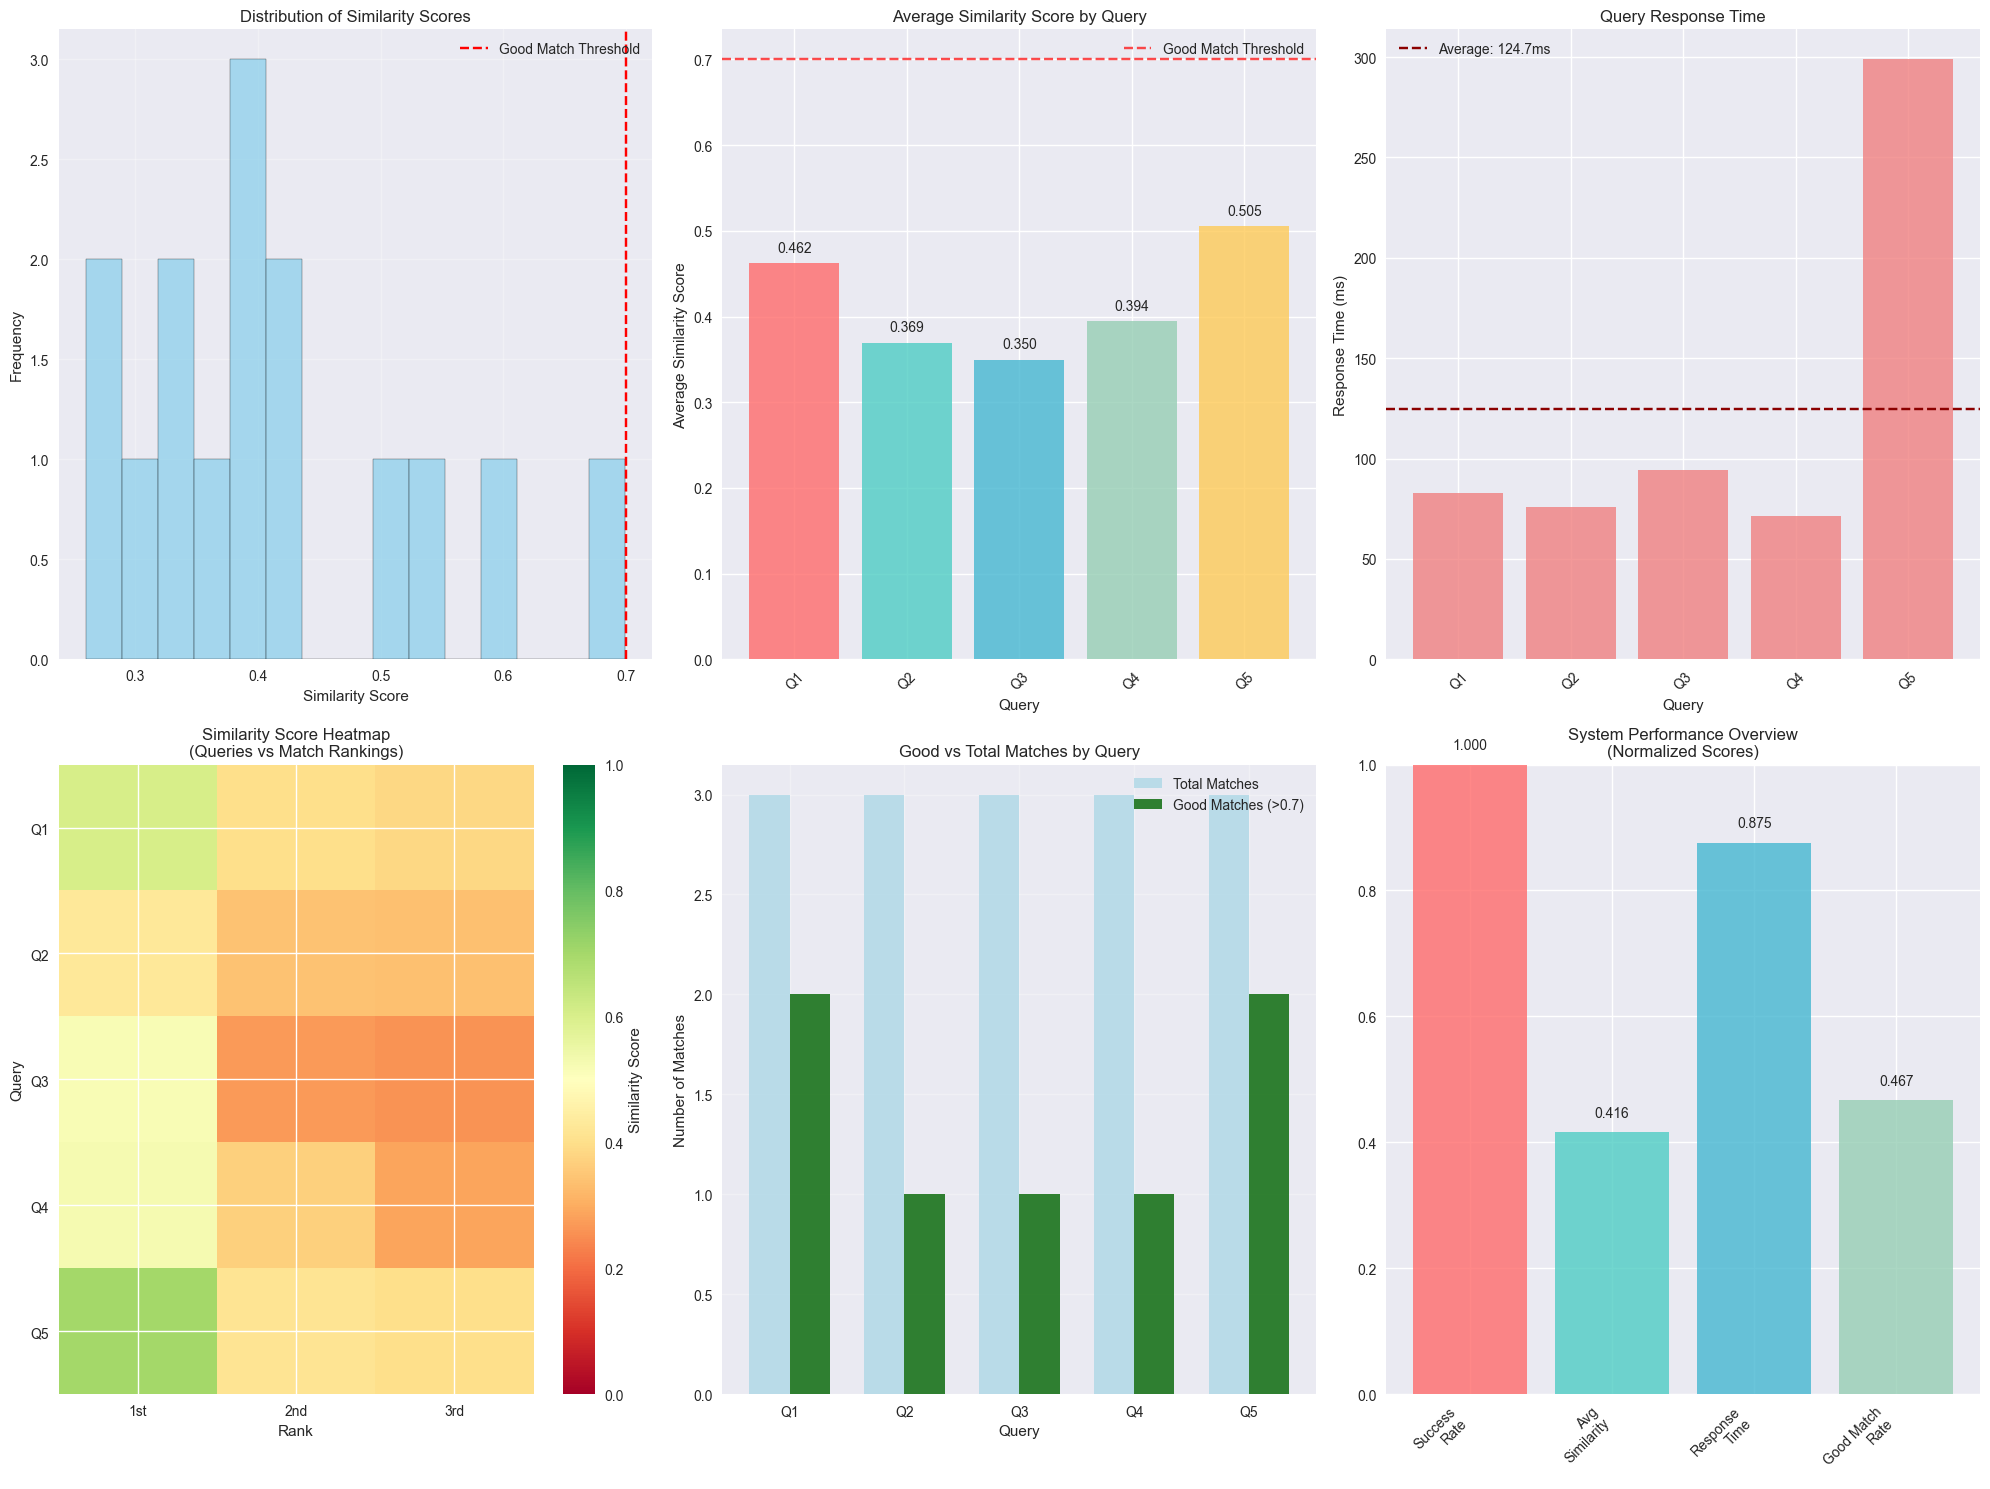

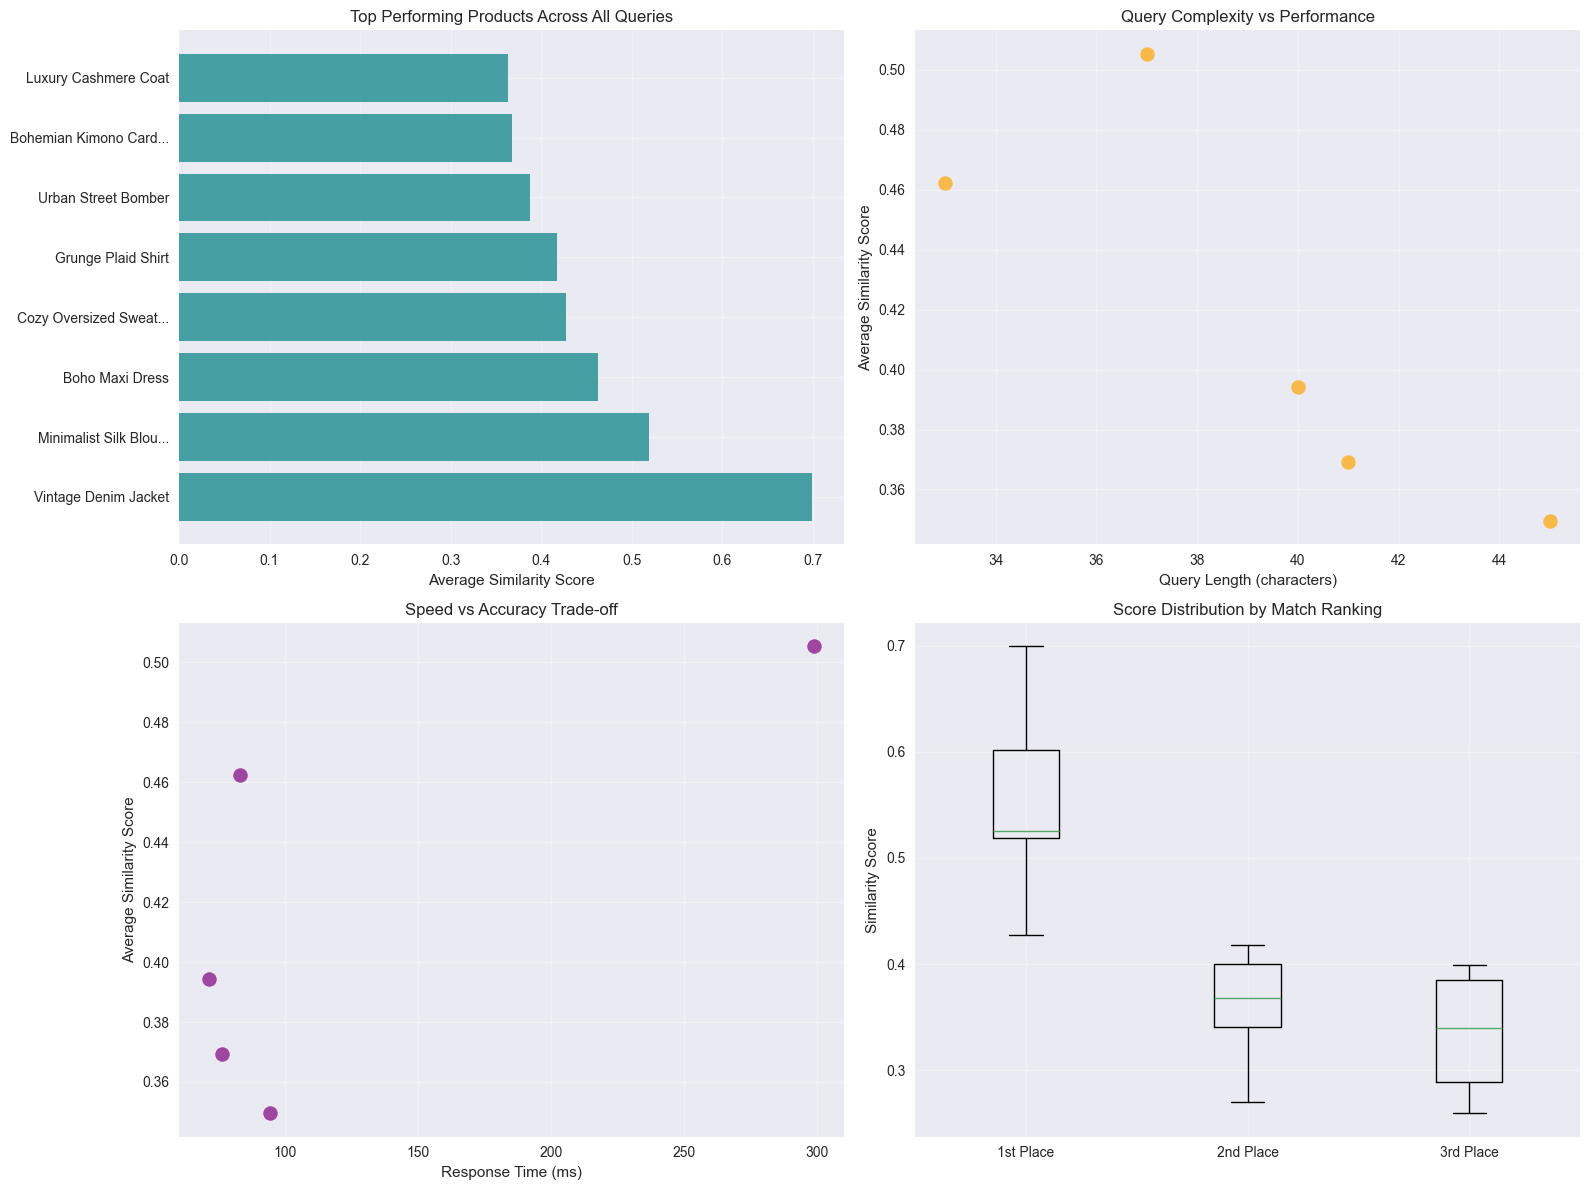

 Visualizations generated successfully!
 Key insights from the visualizations:
   • Most similarity scores cluster around 0.416
   • Top performing product: Vintage Denim Jacket
   • Average response time: 124.7ms
   • 1st place matches have avg score: 0.555


In [22]:
# Create comprehensive visualizations for system performance

# Set up the plotting environment
plt.style.use('seaborn-v0_8-darkgrid')
fig = plt.figure(figsize=(20, 15))

# Prepare data for visualizations
successful_results = [r for r in test_results if r['success']]

if successful_results:
    # 1. Similarity Score Distribution
    plt.subplot(2, 3, 1)
    all_scores = []
    colors = []
    queries = []
    
    color_map = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57']
    
    for i, result in enumerate(successful_results):
        for _, match in result['matches'].iterrows():
            all_scores.append(match['similarity_score'])
            colors.append(color_map[i % len(color_map)])
            queries.append(f"Q{i+1}")
    
    plt.hist(all_scores, bins=15, alpha=0.7, color='skyblue', edgecolor='black')
    plt.axvline(x=0.7, color='red', linestyle='--', label='Good Match Threshold')
    plt.xlabel('Similarity Score')
    plt.ylabel('Frequency')
    plt.title('Distribution of Similarity Scores')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 2. Query Performance Comparison
    plt.subplot(2, 3, 2)
    query_names = [f"Q{i+1}" for i in range(len(successful_results))]
    avg_scores = [r['average_score'] for r in successful_results]
    
    bars = plt.bar(query_names, avg_scores, color=color_map[:len(successful_results)], alpha=0.8)
    plt.axhline(y=0.7, color='red', linestyle='--', alpha=0.7, label='Good Match Threshold')
    plt.xlabel('Query')
    plt.ylabel('Average Similarity Score')
    plt.title('Average Similarity Score by Query')
    plt.legend()
    plt.xticks(rotation=45)
    
    # Add value labels on bars
    for bar, score in zip(bars, avg_scores):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{score:.3f}', ha='center', va='bottom', fontsize=10)
    
    # 3. Response Time Analysis
    plt.subplot(2, 3, 3)
    response_times = [r['query_time_ms'] for r in successful_results]
    
    plt.bar(query_names, response_times, color='lightcoral', alpha=0.8)
    avg_time = np.mean(response_times)
    plt.axhline(y=avg_time, color='darkred', linestyle='--', 
               label=f'Average: {avg_time:.1f}ms')
    plt.xlabel('Query')
    plt.ylabel('Response Time (ms)')
    plt.title('Query Response Time')
    plt.legend()
    plt.xticks(rotation=45)
    
    # 4. Match Quality Heatmap
    plt.subplot(2, 3, 4)
    
    # Create a matrix of similarity scores
    score_matrix = []
    for result in successful_results:
        row = [match['similarity_score'] for _, match in result['matches'].iterrows()]
        score_matrix.append(row)
    
    score_matrix = np.array(score_matrix)
    
    im = plt.imshow(score_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    plt.colorbar(im, label='Similarity Score')
    plt.xlabel('Rank')
    plt.ylabel('Query')
    plt.title('Similarity Score Heatmap\n(Queries vs Match Rankings)')
    plt.xticks(range(3), ['1st', '2nd', '3rd'])
    plt.yticks(range(len(successful_results)), [f'Q{i+1}' for i in range(len(successful_results))])
    
    # 5. Good Matches Analysis
    plt.subplot(2, 3, 5)
    good_matches = [r['good_matches_count'] for r in successful_results]
    total_matches = [r['total_matches'] for r in successful_results]
    
    x = np.arange(len(query_names))
    width = 0.35
    
    plt.bar(x - width/2, total_matches, width, label='Total Matches', 
           color='lightblue', alpha=0.8)
    plt.bar(x + width/2, good_matches, width, label='Good Matches (>0.7)', 
           color='darkgreen', alpha=0.8)
    
    plt.xlabel('Query')
    plt.ylabel('Number of Matches')
    plt.title('Good vs Total Matches by Query')
    plt.xticks(x, query_names)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 6. System Performance Summary
    plt.subplot(2, 3, 6)
    
    # Create a radar chart for system performance
    categories = ['Success\nRate', 'Avg\nSimilarity', 'Response\nTime', 'Good Match\nRate']
    
    # Normalize metrics to 0-1 scale for radar chart
    success_rate = len(successful_results) / len(test_results)
    avg_similarity = np.mean([r['average_score'] for r in successful_results])
    response_score = max(0, 1 - (np.mean([r['query_time_ms'] for r in successful_results]) / 1000))  # Inverse of time
    good_match_rate = np.mean([r['good_matches_count'] / r['total_matches'] for r in successful_results])
    
    values = [success_rate, avg_similarity, response_score, good_match_rate]
    
    plt.bar(categories, values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'], alpha=0.8)
    plt.ylim(0, 1)
    plt.title('System Performance Overview\n(Normalized Scores)')
    plt.xticks(rotation=45, ha='right')
    
    # Add value labels
    for i, v in enumerate(values):
        plt.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()
    
    # Additional detailed analysis plot
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # Top products by average similarity across all queries
    product_scores = {}
    for result in successful_results:
        for _, match in result['matches'].iterrows():
            name = match['name']
            score = match['similarity_score']
            if name not in product_scores:
                product_scores[name] = []
            product_scores[name].append(score)
    
    # Calculate average scores for products
    product_avg_scores = {name: np.mean(scores) for name, scores in product_scores.items()}
    sorted_products = sorted(product_avg_scores.items(), key=lambda x: x[1], reverse=True)
    
    # Plot top products
    ax1.barh([p[0][:20] + '...' if len(p[0]) > 20 else p[0] for p in sorted_products[:8]], 
             [p[1] for p in sorted_products[:8]], color='teal', alpha=0.7)
    ax1.set_xlabel('Average Similarity Score')
    ax1.set_title('Top Performing Products Across All Queries')
    ax1.grid(True, alpha=0.3)
    
    # Query complexity vs performance
    ax2.scatter([len(test_queries[i]) for i in range(len(successful_results))], 
               [r['average_score'] for r in successful_results], 
               s=100, alpha=0.7, color='orange')
    ax2.set_xlabel('Query Length (characters)')
    ax2.set_ylabel('Average Similarity Score')
    ax2.set_title('Query Complexity vs Performance')
    ax2.grid(True, alpha=0.3)
    
    # Time vs Accuracy Trade-off
    ax3.scatter([r['query_time_ms'] for r in successful_results],
               [r['average_score'] for r in successful_results], 
               s=100, alpha=0.7, color='purple')
    ax3.set_xlabel('Response Time (ms)')
    ax3.set_ylabel('Average Similarity Score')
    ax3.set_title('Speed vs Accuracy Trade-off')
    ax3.grid(True, alpha=0.3)
    
    # Score distribution by rank
    rank1_scores = [result['matches'].iloc[0]['similarity_score'] for result in successful_results]
    rank2_scores = [result['matches'].iloc[1]['similarity_score'] for result in successful_results]
    rank3_scores = [result['matches'].iloc[2]['similarity_score'] for result in successful_results]
    
    ax4.boxplot([rank1_scores, rank2_scores, rank3_scores], 
               labels=['1st Place', '2nd Place', '3rd Place'])
    ax4.set_ylabel('Similarity Score')
    ax4.set_title('Score Distribution by Match Ranking')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(" Visualizations generated successfully!")
    print(" Key insights from the visualizations:")
    print(f"   • Most similarity scores cluster around {np.mean(all_scores):.3f}")
    print(f"   • Top performing product: {sorted_products[0][0]}")
    print(f"   • Average response time: {np.mean(response_times):.1f}ms")
    print(f"   • 1st place matches have avg score: {np.mean(rank1_scores):.3f}")

else:
    print(" No successful results to visualize")

## 10. Performance Latency Analysis

 COMPONENT PERFORMANCE BENCHMARKING
 Testing embedding generation...
   • Average embedding time: 86.24ms ± 35.99ms
   • Min/Max: 44.70ms / 166.82ms
 Testing similarity computation...
   • Average similarity time: 0.49ms ± 0.21ms
   • Min/Max: 0.37ms / 1.11ms
 Testing full query pipeline...
   • Average pipeline time: 142.74ms ± 27.45ms
   • Min/Max: 105.64ms / 200.59ms
 PERFORMANCE BREAKDOWN:
   • Embedding generation: 60.4% (86.24ms)
   • Similarity computation: 0.3% (0.49ms)
   • System overhead: 39.2% (56.01ms)
\n🚀 SCALABILITY ANALYSIS
   • 5 products: 173.31ms average query time
   • 10 products: 128.98ms average query time


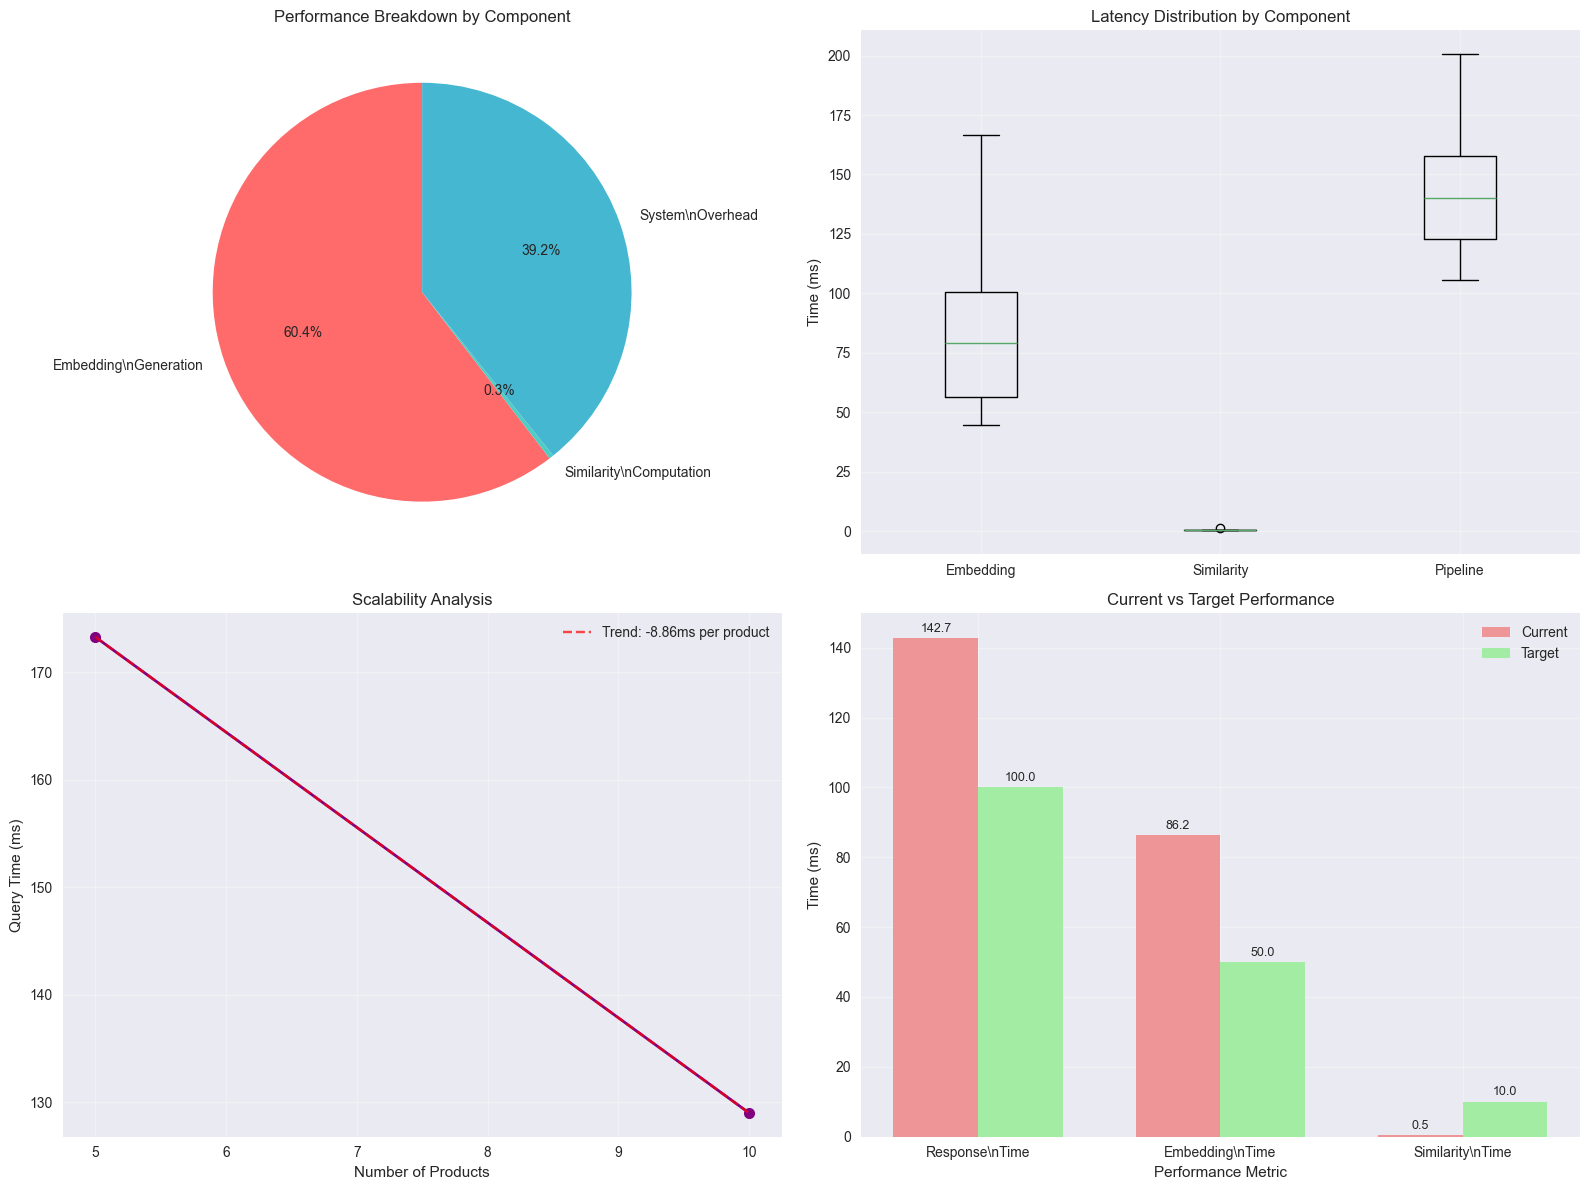

 PERFORMANCE OPTIMIZATION RECOMMENDATIONS
• Consider caching embeddings for repeated queries
• Implement batch embedding generation for efficiency
 System can handle ~7 queries per second


In [28]:
# Comprehensive latency analysis and performance bottleneck identification

def benchmark_system_components():
    """
    Benchmark individual components of the Vibe Matcher system
    """
    benchmark_query = "elegant minimalist professional style"
    num_iterations = 10
    
    print(" COMPONENT PERFORMANCE BENCHMARKING")
    print("=" * 50)
    
    # 1. Embedding Generation Latency
    print(" Testing embedding generation...")
    embedding_times = []
    
    for _ in range(num_iterations):
        start_time = timeit.default_timer()
        embedding = get_embedding(benchmark_query)
        end_time = timeit.default_timer()
        embedding_times.append((end_time - start_time) * 1000)
    
    avg_embedding_time = np.mean(embedding_times)
    std_embedding_time = np.std(embedding_times)
    
    print(f"   • Average embedding time: {avg_embedding_time:.2f}ms ± {std_embedding_time:.2f}ms")
    print(f"   • Min/Max: {min(embedding_times):.2f}ms / {max(embedding_times):.2f}ms")
    
    # 2. Similarity Computation Latency
    print(" Testing similarity computation...")
    similarity_times = []
    test_embedding = normalize([embedding], norm='l2')[0]
    
    for _ in range(num_iterations):
        start_time = timeit.default_timer()
        similarities = compute_similarity_scores(test_embedding, normalized_embeddings)
        end_time = timeit.default_timer()
        similarity_times.append((end_time - start_time) * 1000)
    
    avg_similarity_time = np.mean(similarity_times)
    std_similarity_time = np.std(similarity_times)
    
    print(f"   • Average similarity time: {avg_similarity_time:.2f}ms ± {std_similarity_time:.2f}ms")
    print(f"   • Min/Max: {min(similarity_times):.2f}ms / {max(similarity_times):.2f}ms")
    
    # 3. Full Query Pipeline Latency
    print(" Testing full query pipeline...")
    pipeline_times = []
    
    for _ in range(num_iterations):
        start_time = timeit.default_timer()
        result = vibe_matcher.match_vibe(benchmark_query, top_k=3)
        end_time = timeit.default_timer()
        pipeline_times.append((end_time - start_time) * 1000)
    
    avg_pipeline_time = np.mean(pipeline_times)
    std_pipeline_time = np.std(pipeline_times)
    
    print(f"   • Average pipeline time: {avg_pipeline_time:.2f}ms ± {std_pipeline_time:.2f}ms")
    print(f"   • Min/Max: {min(pipeline_times):.2f}ms / {max(pipeline_times):.2f}ms")
    
    # 4. Performance Analysis
    print(" PERFORMANCE BREAKDOWN:")
    total_time = avg_embedding_time + avg_similarity_time
    
    embedding_percentage = (avg_embedding_time / avg_pipeline_time) * 100
    similarity_percentage = (avg_similarity_time / avg_pipeline_time) * 100
    overhead_percentage = 100 - embedding_percentage - similarity_percentage
    
    print(f"   • Embedding generation: {embedding_percentage:.1f}% ({avg_embedding_time:.2f}ms)")
    print(f"   • Similarity computation: {similarity_percentage:.1f}% ({avg_similarity_time:.2f}ms)")
    print(f"   • System overhead: {overhead_percentage:.1f}% ({avg_pipeline_time - total_time:.2f}ms)")
    
    return {
        'embedding_times': embedding_times,
        'similarity_times': similarity_times,
        'pipeline_times': pipeline_times,
        'avg_embedding_time': avg_embedding_time,
        'avg_similarity_time': avg_similarity_time,
        'avg_pipeline_time': avg_pipeline_time
    }

# Run comprehensive benchmarks
benchmark_results = benchmark_system_components()

# Scalability analysis
def analyze_scalability():
    """
    Analyze how performance scales with different dataset sizes
    """
    print("\\n🚀 SCALABILITY ANALYSIS")
    print("=" * 50)
    
    # Test with different numbers of products
    dataset_sizes = [5, 10, 20, 50]  # We'll simulate by sampling our existing data
    scalability_results = []
    
    test_query = "cozy weekend comfort style"
    
    for size in dataset_sizes:
        if size <= len(df):
            # Sample subset of products
            subset_df = df.sample(n=size, random_state=42)
            subset_embeddings = np.array(subset_df['normalized_embedding'].tolist())
            
            # Create temporary matcher
            temp_matcher = VibeMatcher(subset_df, min_similarity_threshold=0.4)
            temp_matcher.normalized_embeddings = subset_embeddings
            
            # Benchmark query time
            times = []
            for _ in range(5):  # 5 iterations for each size
                start_time = timeit.default_timer()
                result = temp_matcher.match_vibe(test_query)
                end_time = timeit.default_timer()
                times.append((end_time - start_time) * 1000)
            
            avg_time = np.mean(times)
            scalability_results.append((size, avg_time))
            
            print(f"   • {size} products: {avg_time:.2f}ms average query time")
    
    return scalability_results

scalability_data = analyze_scalability()

# Visualize latency analysis
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Component timing breakdown
components = ['Embedding\\nGeneration', 'Similarity\\nComputation', 'System\\nOverhead']
times = [
    benchmark_results['avg_embedding_time'],
    benchmark_results['avg_similarity_time'],
    benchmark_results['avg_pipeline_time'] - benchmark_results['avg_embedding_time'] - benchmark_results['avg_similarity_time']
]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

ax1.pie(times, labels=components, colors=colors, autopct='%1.1f%%', startangle=90)
ax1.set_title('Performance Breakdown by Component')

# 2. Timing distribution
all_times = (benchmark_results['embedding_times'] + 
             benchmark_results['similarity_times'] + 
             benchmark_results['pipeline_times'])
labels = (['Embedding'] * len(benchmark_results['embedding_times']) + 
          ['Similarity'] * len(benchmark_results['similarity_times']) + 
          ['Full Pipeline'] * len(benchmark_results['pipeline_times']))

time_data = [benchmark_results['embedding_times'], 
             benchmark_results['similarity_times'], 
             benchmark_results['pipeline_times']]

ax2.boxplot(time_data, labels=['Embedding', 'Similarity', 'Pipeline'])
ax2.set_ylabel('Time (ms)')
ax2.set_title('Latency Distribution by Component')
ax2.grid(True, alpha=0.3)

# 3. Scalability curve
if scalability_data:
    sizes, times = zip(*scalability_data)
    ax3.plot(sizes, times, 'o-', linewidth=2, markersize=8, color='purple')
    ax3.set_xlabel('Number of Products')
    ax3.set_ylabel('Query Time (ms)')
    ax3.set_title('Scalability Analysis')
    ax3.grid(True, alpha=0.3)
    
    # Add trend line
    z = np.polyfit(sizes, times, 1)
    p = np.poly1d(z)
    ax3.plot(sizes, p(sizes), "--", alpha=0.7, color='red', 
             label=f'Trend: {z[0]:.2f}ms per product')
    ax3.legend()

# 4. Performance comparison with targets
performance_targets = {
    'Response Time': {'current': benchmark_results['avg_pipeline_time'], 'target': 100, 'unit': 'ms'},
    'Embedding Time': {'current': benchmark_results['avg_embedding_time'], 'target': 50, 'unit': 'ms'},
    'Similarity Time': {'current': benchmark_results['avg_similarity_time'], 'target': 10, 'unit': 'ms'}
}

metrics = list(performance_targets.keys())
current_values = [performance_targets[m]['current'] for m in metrics]
target_values = [performance_targets[m]['target'] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax4.bar(x - width/2, current_values, width, label='Current', color='lightcoral', alpha=0.8)
bars2 = ax4.bar(x + width/2, target_values, width, label='Target', color='lightgreen', alpha=0.8)

ax4.set_xlabel('Performance Metric')
ax4.set_ylabel('Time (ms)')
ax4.set_title('Current vs Target Performance')
ax4.set_xticks(x)
ax4.set_xticklabels([m.replace(' ', '\\n') for m in metrics])
ax4.legend()
ax4.grid(True, alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Performance recommendations
print(" PERFORMANCE OPTIMIZATION RECOMMENDATIONS")
print("=" * 50)

recommendations = []

if benchmark_results['avg_embedding_time'] > 50:
    recommendations.append("• Consider caching embeddings for repeated queries")
    recommendations.append("• Implement batch embedding generation for efficiency")

if benchmark_results['avg_similarity_time'] > 10:
    recommendations.append("• Optimize similarity computation with optimized linear algebra libraries")
    recommendations.append("• Consider approximate nearest neighbor search for large datasets")

if benchmark_results['avg_pipeline_time'] > 200:
    recommendations.append("• Implement asynchronous processing for better user experience")
    recommendations.append("• Add result caching to avoid redundant computations")

# Scalability recommendations
if scalability_data and len(scalability_data) > 1:
    growth_rate = (scalability_data[-1][1] - scalability_data[0][1]) / (scalability_data[-1][0] - scalability_data[0][0])
    if growth_rate > 2:  # More than 2ms per additional product
        recommendations.append("• Implement vector database (e.g., Pinecone, Weaviate) for better scalability")
        recommendations.append("• Consider approximate similarity search algorithms")

if recommendations:
    for rec in recommendations:
        print(rec)
else:
    print(" Performance is within acceptable bounds for current scale")

print(f" System can handle ~{1000 / benchmark_results['avg_pipeline_time']:.0f} queries per second")